In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df_rate = pd.read_csv('/content/drive/My Drive/BTLdataMining/rating.csv')
df_anime = pd.read_csv('/content/drive/My Drive/BTLdataMining/anime.csv')

In [ ]:
Name = list(df_anime["type"].unique())
Qnt = [len(df_anime[df_anime["type"] == e]) for e in Name]
Name = Name[:-1]
Qnt = Qnt[:-1]

In [ ]:
print(Name)
print(Qnt)

['Movie', 'TV', 'OVA', 'Special', 'Music', 'ONA']
[2348, 3787, 3311, 1676, 488, 659]


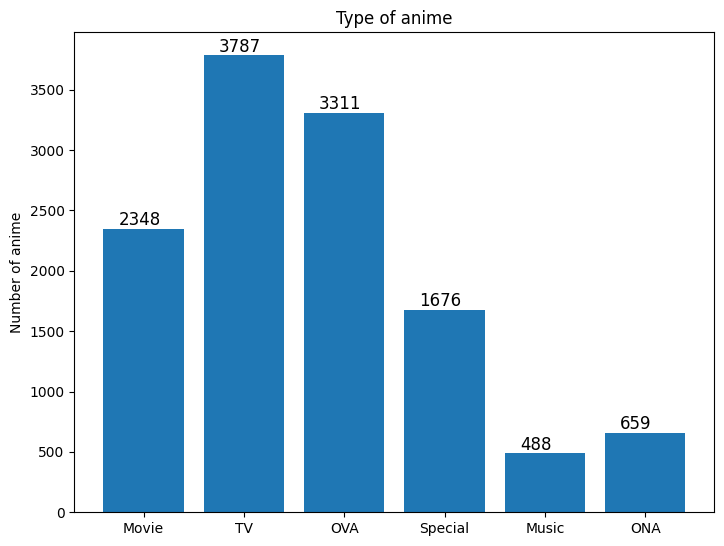

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_title('Type of anime')
ax.set_ylabel('Number of anime')
ax.bar(Name,Qnt)

for index,data in enumerate(Qnt):
    plt.text(x=index-0.25 , y =data+30, s=f"{data}" , fontdict=dict(fontsize=12))
plt.show()

In [ ]:
Genre = dict()

for i in range(len(df_anime)):
    str_genre = df_anime.loc[i, "genre"]
    if pd.isnull(str_genre):
        print(i,end=" ")
        continue
    Arr = str_genre.strip().split(", ")
    for j in Arr:
        if j not in Genre:
            Genre[ j ] = 1
        else :
            Genre[ j ] += 1

_name = sorted(list(Genre.keys()) ,key = lambda x:-Genre[x])
_value = [ Genre[e] for e in _name]

2844 3541 6040 6646 7018 7198 7335 7349 7426 7498 7591 7645 7685 7708 7716 7738 7759 7824 7876 7899 7982 8235 8279 8304 8565 8716 8766 8897 8900 8938 8955 9105 9137 9142 9171 9265 9413 9559 9903 9978 10153 10243 10424 10575 10719 10807 10863 10925 10956 10982 10983 10990 10992 11020 11046 11050 11064 11070 11086 11097 11112 11113 

In [ ]:
_name[:10],_value[:10]

(['Comedy',
  'Action',
  'Adventure',
  'Fantasy',
  'Sci-Fi',
  'Drama',
  'Shounen',
  'Kids',
  'Romance',
  'School'],
 [4645, 2845, 2348, 2309, 2070, 2016, 1712, 1609, 1464, 1220])

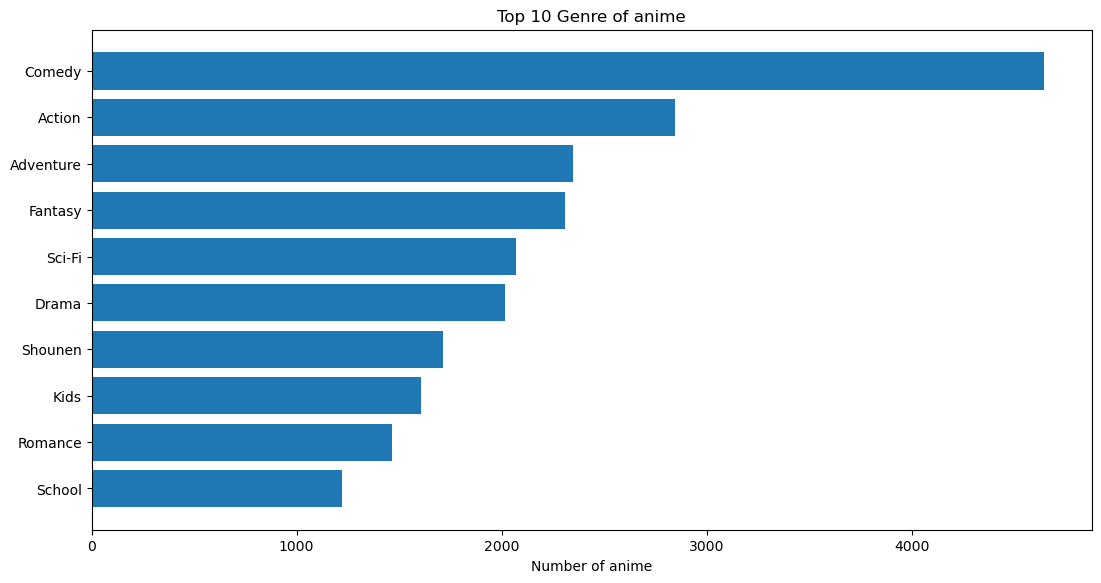

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,5))
ax = fig.add_axes([0,0,1,1])
ax.set_title('Top 10 Genre of anime')
ax.barh(_name[:10][::-1],_value[:10][::-1])
ax.set_xlabel('Number of anime')
plt.show()

## data processing

In [ ]:
 df_anime[df_anime["type"] == "Music"]

,anime_id,name,genre,type,episodes,rating,members
169,34240,Shelter,"Music, Sci-Fi",Music,1,8.38,71136
336,731,Interstella5555: The 5tory of The 5ecret 5tar ...,"Adventure, Drama, Music, Sci-Fi",Music,1,8.17,31464
533,17949,The Everlasting Guilty Crown,Music,Music,1,8.00,11663
1178,2768,CLAMP in Wonderland 2,"Action, Comedy, Drama, Fantasy, Magic, Music, ...",Music,1,7.64,13985
1267,9930,Snow Halation,Music,Music,1,7.61,8731
...,...,...,...,...,...,...,...
10808,33908,Yasoukyoku,Music,Music,1,5.14,82
10815,29970,Yell,Music,Music,1,5.46,55
10837,30169,Yubikiri,Music,Music,1,4.54,75
10841,31872,Yukidaruma Kazoku,"Kids, Music",Music,1,5.25,40


In [ ]:
df_anime[df_anime["type"] == 'OVA']["anime_id"].values

array([  820,    44, 32366, ...,  5543,  5621,  6133])

In [ ]:
set_tv = set(df_anime[df_anime["type"] == 'TV']["anime_id"].values)
set_movie = set(df_anime[df_anime["type"] == 'Movie']["anime_id"].values)
set_ova = set(df_anime[df_anime["type"] == 'OVA']["anime_id"].values)

In [ ]:
dType = {'Movie':[], 'TV':[], 'OVA':[], 'Special':[], 'Music':[], 'ONA':[]}
grouped = df_rate.groupby("user_id")
k = 0
who_skipped = [46809]

for i in range(73515):
    if i+1 in who_skipped:
        continue
    A = grouped.get_group(i+1)

    B = A[A['rating']>=1]
    set_trans = set(B['anime_id'].values)

    adding_tv = list(set_tv.intersection(set_trans))
    if len(adding_tv)>1:
        dType['TV'].append(adding_tv)

    adding_movie = list(set_movie.intersection(set_trans))
    if len(adding_movie)>1:
        dType['Movie'].append(adding_movie)

    adding_ova = list(set_ova.intersection(set_trans))
    if len(adding_ova)>1:
        dType['OVA'].append(adding_ova)


In [ ]:
print(len(dType['TV']),len(dType['Movie']),len(dType['OVA']))

65333 44192 38412


In [ ]:
!pip install efficient-apriori

In [ ]:
def get_rule_with_name(_rule,df):
    _str  = ""
    Left  = []
    Right = []
    for i in _rule.lhs:
        Left  += [" "+df[df['anime_id']==i].reset_index().loc[0,'name']]
    for j in _rule.rhs:
        Right += [" "+df[df['anime_id']==j].reset_index().loc[0,'name']]

    _str += '{'+", ".join(Left)+' }'
    _str += " => "+'{'+", ".join(Right)+' }'

    conf = "conf: {0:.3f}".format(_rule.confidence)
    supp = "supp: {0:.3f}".format(_rule.support)
    _str += "\n({}, {})".format(conf, supp)
    return _str

In [ ]:
from efficient_apriori import apriori #https://efficient-apriori.readthedocs.io/en/latest/
itemsets, rules = apriori( dType['TV'],min_support=0.25, min_confidence=0.7)

In [ ]:
itemsets, rules = apriori( dType['TV'], min_support=0.2, min_confidence=0.2)

In [ ]:
print(rules,len(rules))

[{1535} -> {20}, {20} -> {1535}, {1535} -> {121}, {121} -> {1535}, {1535} -> {226}, {226} -> {1535}, {1575} -> {1535}, {1535} -> {1575}, {2904} -> {1535}, {1535} -> {2904}, {4224} -> {1535}, {1535} -> {4224}, {5114} -> {1535}, {1535} -> {5114}, {6547} -> {1535}, {1535} -> {6547}, {8074} -> {1535}, {1535} -> {8074}, {10620} -> {1535}, {1535} -> {10620}, {11757} -> {1535}, {1535} -> {11757}, {16498} -> {1535}, {1535} -> {16498}, {2904} -> {1575}, {1575} -> {2904}, {11757} -> {1575}, {1575} -> {11757}, {4181} -> {2167}, {2167} -> {4181}, {11757} -> {5114}, {5114} -> {11757}, {16498} -> {5114}, {5114} -> {16498}, {11757} -> {6547}, {6547} -> {11757}, {16498} -> {6547}, {6547} -> {16498}, {11757} -> {10620}, {10620} -> {11757}, {16498} -> {11757}, {11757} -> {16498}, {1575, 2904} -> {1535}, {1535, 2904} -> {1575}, {1535, 1575} -> {2904}, {2904} -> {1535, 1575}, {1575} -> {1535, 2904}, {1535} -> {1575, 2904}] 48


In [ ]:
itemsets, rules = apriori( dType['TV'], min_support=0.2, min_confidence=0.5)
print(rules,len(rules))

[{20} -> {1535}, {121} -> {1535}, {1535} -> {226}, {226} -> {1535}, {1575} -> {1535}, {1535} -> {1575}, {2904} -> {1535}, {4224} -> {1535}, {5114} -> {1535}, {6547} -> {1535}, {8074} -> {1535}, {10620} -> {1535}, {11757} -> {1535}, {16498} -> {1535}, {1535} -> {16498}, {2904} -> {1575}, {1575} -> {2904}, {1575} -> {11757}, {4181} -> {2167}, {2167} -> {4181}, {11757} -> {5114}, {5114} -> {11757}, {16498} -> {5114}, {5114} -> {16498}, {11757} -> {6547}, {6547} -> {11757}, {16498} -> {6547}, {6547} -> {16498}, {11757} -> {10620}, {10620} -> {11757}, {16498} -> {11757}, {11757} -> {16498}, {1575, 2904} -> {1535}, {1535, 2904} -> {1575}, {1535, 1575} -> {2904}, {2904} -> {1535, 1575}, {1575} -> {1535, 2904}] 37


In [ ]:
#print(rules[0].lhs, rules[0].rhs)
#print(rules)
#print(itemsets)

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

{ Naruto } => { Death Note }
(conf: 0.707, supp: 0.237)

{ Fullmetal Alchemist } => { Death Note }
(conf: 0.716, supp: 0.233)

{ Death Note } => { Elfen Lied }
(conf: 0.501, supp: 0.261)

{ Elfen Lied } => { Death Note }
(conf: 0.726, supp: 0.261)

{ Code Geass: Hangyaku no Lelouch } => { Death Note }
(conf: 0.748, supp: 0.276)

{ Death Note } => { Code Geass: Hangyaku no Lelouch }
(conf: 0.529, supp: 0.276)

{ Code Geass: Hangyaku no Lelouch R2 } => { Death Note }
(conf: 0.762, supp: 0.246)

{ Toradora! } => { Death Note }
(conf: 0.647, supp: 0.206)

{ Fullmetal Alchemist: Brotherhood } => { Death Note }
(conf: 0.727, supp: 0.239)

{ Angel Beats! } => { Death Note }
(conf: 0.649, supp: 0.234)

{ Highschool of the Dead } => { Death Note }
(conf: 0.703, supp: 0.210)

{ Mirai Nikki (TV) } => { Death Note }
(conf: 0.720, supp: 0.205)

{ Sword Art Online } => { Death Note }
(conf: 0.643, supp: 0.258)

{ Shingeki no Kyojin } => { Death Note }
(conf: 0.682, supp: 0.263)

{ Death Note } => { 

In [ ]:
#print(rules[0].lhs, rules[0].rhs)
#print(rules)
#print(itemsets)

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

{ Elfen Lied } => { Death Note }
(conf: 0.726, supp: 0.261)

{ Code Geass: Hangyaku no Lelouch } => { Death Note }
(conf: 0.748, supp: 0.276)

{ Code Geass: Hangyaku no Lelouch R2 } => { Code Geass: Hangyaku no Lelouch }
(conf: 0.977, supp: 0.316)

{ Code Geass: Hangyaku no Lelouch } => { Code Geass: Hangyaku no Lelouch R2 }
(conf: 0.856, supp: 0.316)

{ Shingeki no Kyojin } => { Sword Art Online }
(conf: 0.708, supp: 0.273)



In [ ]:
from efficient_apriori import apriori #https://efficient-apriori.readthedocs.io/en/latest/
itemsets, rules = apriori( dType['Movie'],min_support=0.2, min_confidence=0.5)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{199} -> {164}, {164} -> {199}, {431} -> {164}, {164} -> {431}, {431} -> {199}, {199} -> {431}] 6

{ Sen to Chihiro no Kamikakushi } => { Mononoke Hime }
(conf: 0.562, supp: 0.243)

{ Mononoke Hime } => { Sen to Chihiro no Kamikakushi }
(conf: 0.793, supp: 0.243)

{ Howl no Ugoku Shiro } => { Mononoke Hime }
(conf: 0.623, supp: 0.203)

{ Mononoke Hime } => { Howl no Ugoku Shiro }
(conf: 0.662, supp: 0.203)

{ Howl no Ugoku Shiro } => { Sen to Chihiro no Kamikakushi }
(conf: 0.825, supp: 0.269)

{ Sen to Chihiro no Kamikakushi } => { Howl no Ugoku Shiro }
(conf: 0.622, supp: 0.269)



In [ ]:
itemsets, rules = apriori( dType['Movie'],min_support=0.1, min_confidence=0.5)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{32} -> {199}, {2759} -> {32}, {32} -> {2759}, {43} -> {199}, {47} -> {164}, {47} -> {199}, {199} -> {164}, {164} -> {199}, {431} -> {164}, {164} -> {431}, {512} -> {164}, {513} -> {164}, {523} -> {164}, {572} -> {164}, {578} -> {164}, {2236} -> {164}, {317} -> {199}, {430} -> {199}, {431} -> {199}, {199} -> {431}, {512} -> {199}, {513} -> {199}, {523} -> {199}, {572} -> {199}, {578} -> {199}, {1689} -> {199}, {2236} -> {199}, {2890} -> {199}, {5681} -> {199}, {12355} -> {199}, {512} -> {431}, {513} -> {431}, {523} -> {431}, {431} -> {523}, {572} -> {431}, {578} -> {431}, {2236} -> {431}, {2890} -> {431}, {512} -> {523}, {2889} -> {1686}, {1686} -> {2889}, {4835} -> {1686}, {1686} -> {4835}, {2236} -> {1689}, {1689} -> {2236}, {5681} -> {2236}, {3782} -> {2593}, {2593} -> {3782}, {3783} -> {2593}, {2593} -> {3783}, {3784} -> {2759}, {2759} -> {3784}, {4835} -> {2889}, {2889} -> {4835}, {3783} -> {3782}, {3782} -> {3783}, {199, 431} -> {164}, {164, 431} -> {199}, {164, 199} -> {431}, {

{ Sen to Chihiro no Kamikakushi,  Majo no Takkyuubin } => { Mononoke Hime }
(conf: 0.784, supp: 0.102)

{ Mononoke Hime,  Majo no Takkyuubin } => { Sen to Chihiro no Kamikakushi }
(conf: 0.940, supp: 0.102)

{ Majo no Takkyuubin } => { Mononoke Hime,  Sen to Chihiro no Kamikakushi }
(conf: 0.701, supp: 0.102)

{ Sen to Chihiro no Kamikakushi,  Tenkuu no Shiro Laputa } => { Mononoke Hime }
(conf: 0.827, supp: 0.104)

{ Mononoke Hime,  Tenkuu no Shiro Laputa } => { Sen to Chihiro no Kamikakushi }
(conf: 0.936, supp: 0.104)

{ Tenkuu no Shiro Laputa } => { Mononoke Hime,  Sen to Chihiro no Kamikakushi }
(conf: 0.735, supp: 0.104)

{ Sen to Chihiro no Kamikakushi,  Tonari no Totoro } => { Mononoke Hime }
(conf: 0.707, supp: 0.140)

{ Mononoke Hime,  Tonari no Totoro } => { Sen to Chihiro no Kamikakushi }
(conf: 0.916, supp: 0.140)

{ Mononoke Hime,  Sen to Chihiro no Kamikakushi } => { Tonari no Totoro }
(conf: 0.577, supp: 0.140)

{ Tonari no Totoro } => { Mononoke Hime,  Sen to Chihiro n

In [ ]:
itemsets, rules = apriori( dType['Movie'],min_support=0.2, min_confidence=0.2)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{199} -> {164}, {164} -> {199}, {431} -> {164}, {164} -> {431}, {431} -> {199}, {199} -> {431}] 6

{ Sen to Chihiro no Kamikakushi } => { Mononoke Hime }
(conf: 0.562, supp: 0.243)

{ Mononoke Hime } => { Sen to Chihiro no Kamikakushi }
(conf: 0.793, supp: 0.243)

{ Howl no Ugoku Shiro } => { Mononoke Hime }
(conf: 0.623, supp: 0.203)

{ Mononoke Hime } => { Howl no Ugoku Shiro }
(conf: 0.662, supp: 0.203)

{ Howl no Ugoku Shiro } => { Sen to Chihiro no Kamikakushi }
(conf: 0.825, supp: 0.269)

{ Sen to Chihiro no Kamikakushi } => { Howl no Ugoku Shiro }
(conf: 0.622, supp: 0.269)



In [ ]:
itemsets, rules = apriori( dType['OVA'],min_support=0.05, min_confidence=0.9)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{401} -> {44}, {137} -> {138}, {139} -> {138}, {138} -> {139}, {2131} -> {357}] 5

{ Rurouni Kenshin: Meiji Kenkaku Romantan - Seisou-hen } => { Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-hen }
(conf: 0.904, supp: 0.056)

{ Hunter x Hunter OVA } => { Hunter x Hunter: Greed Island }
(conf: 0.903, supp: 0.052)

{ Hunter x Hunter: Greed Island Final } => { Hunter x Hunter: Greed Island }
(conf: 0.938, supp: 0.057)

{ Hunter x Hunter: Greed Island } => { Hunter x Hunter: Greed Island Final }
(conf: 0.916, supp: 0.057)

{ Bokusatsu Tenshi Dokuro-chan 2 } => { Bokusatsu Tenshi Dokuro-chan }
(conf: 0.988, supp: 0.091)



In [ ]:
itemsets, rules = apriori( dType['OVA'],min_support=0.05, min_confidence=0.2)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{227} -> {44}, {44} -> {227}, {401} -> {44}, {44} -> {401}, {138} -> {137}, {137} -> {138}, {139} -> {137}, {137} -> {139}, {139} -> {138}, {138} -> {139}, {268} -> {227}, {227} -> {268}, {357} -> {227}, {227} -> {357}, {777} -> {227}, {227} -> {777}, {3702} -> {227}, {7059} -> {227}, {227} -> {7059}, {2131} -> {357}, {357} -> {2131}] 21

{ FLCL } => { Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-hen }
(conf: 0.201, supp: 0.053)

{ Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-hen } => { FLCL }
(conf: 0.436, supp: 0.053)

{ Rurouni Kenshin: Meiji Kenkaku Romantan - Seisou-hen } => { Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-hen }
(conf: 0.904, supp: 0.056)

{ Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-hen } => { Rurouni Kenshin: Meiji Kenkaku Romantan - Seisou-hen }
(conf: 0.460, supp: 0.056)

{ Hunter x Hunter: Greed Island } => { Hunter x Hunter OVA }
(conf: 0.845, supp: 0.052)

{ Hunter x Hunter OVA } => { Hunter x Hunter: Greed Island }
(conf: 0.903, supp: 

In [ ]:
df_anime[df_anime["anime_id"] == 138]

,anime_id,name,genre,type,episodes,rating,members
202,138,Hunter x Hunter: Greed Island,"Action, Adventure, Shounen, Super Power",OVA,8,8.33,57029


### Run Association Rule (By genre) Comedy, Action, Adventure and Fantasy

In [ ]:
#Comedy, Action, Adventure and Fantasy
set_genre = {'Comedy':set(),'Action':set() ,'Adventure':set(),'Fantasy':set()}

for i in range(len(df_anime)):
    str_genre = df_anime.loc[i, "genre"]
    if pd.isnull(str_genre):
        print(i,end=" ")
        continue
    Arr = str_genre.strip().split(", ")
    for j in Arr:
        if j in set_genre.keys():
            set_genre[ j ].add(df_anime.loc[i,"anime_id"])

2844 3541 6040 6646 7018 7198 7335 7349 7426 7498 7591 7645 7685 7708 7716 7738 7759 7824 7876 7899 7982 8235 8279 8304 8565 8716 8766 8897 8900 8938 8955 9105 9137 9142 9171 9265 9413 9559 9903 9978 10153 10243 10424 10575 10719 10807 10863 10925 10956 10982 10983 10990 10992 11020 11046 11050 11064 11070 11086 11097 11112 11113 

In [ ]:
dGenre = {'Comedy':[], 'Action':[], 'Adventure':[], 'Fantasy':[]}
grouped = df_rate.groupby("user_id")
k = 0
who_skipped = [46809]
#limit_rate = 100000

for i in range(73515):
    if i+1 in who_skipped:
        continue
    A = grouped.get_group(i+1)

    #for j in range(len(A)):
    B = A[A['rating']>=1]
    set_trans = set(B['anime_id'].values)

    for j in dGenre.keys():
        adding = list(set_genre[j].intersection(set_trans))
        if len(adding)>1:
            dGenre[j].append(adding)

In [ ]:
print("Type")
for i in dType.keys():
    print(i,len(dType[i]))
print()
print("Genre")
for i in dGenre.keys():
    print(i,len(dGenre[i]))

Type
Movie 44192
TV 65333
OVA 38412
Special 0
Music 0
ONA 0

Genre
Comedy 62088
Action 61643
Adventure 55876
Fantasy 57993


In [ ]:
itemsets, rules = apriori( dGenre['Comedy'],min_support=0.2, min_confidence=0.5)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{6547} -> {2167}, {2167} -> {6547}, {6547} -> {4224}, {4224} -> {6547}] 4

{ Angel Beats! } => { Clannad }
(conf: 0.531, supp: 0.200)

{ Clannad } => { Angel Beats! }
(conf: 0.665, supp: 0.200)

{ Angel Beats! } => { Toradora! }
(conf: 0.554, supp: 0.209)

{ Toradora! } => { Angel Beats! }
(conf: 0.624, supp: 0.209)



In [ ]:
itemsets, rules = apriori( dGenre['Comedy'],min_support=0.2, min_confidence=0.2)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{6547} -> {2167}, {2167} -> {6547}, {6547} -> {4224}, {4224} -> {6547}] 4

{ Angel Beats! } => { Clannad }
(conf: 0.531, supp: 0.200)

{ Clannad } => { Angel Beats! }
(conf: 0.665, supp: 0.200)

{ Angel Beats! } => { Toradora! }
(conf: 0.554, supp: 0.209)

{ Toradora! } => { Angel Beats! }
(conf: 0.624, supp: 0.209)



In [ ]:
itemsets, rules = apriori( dGenre['Action'],min_support=0.25, min_confidence=0.6)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{2904} -> {1575}, {1575} -> {2904}, {6547} -> {11757}, {16498} -> {11757}, {11757} -> {16498}] 5

{ Code Geass: Hangyaku no Lelouch R2 } => { Code Geass: Hangyaku no Lelouch }
(conf: 0.978, supp: 0.335)

{ Code Geass: Hangyaku no Lelouch } => { Code Geass: Hangyaku no Lelouch R2 }
(conf: 0.858, supp: 0.335)

{ Angel Beats! } => { Sword Art Online }
(conf: 0.660, supp: 0.250)

{ Shingeki no Kyojin } => { Sword Art Online }
(conf: 0.712, supp: 0.290)

{ Sword Art Online } => { Shingeki no Kyojin }
(conf: 0.684, supp: 0.290)



In [ ]:
itemsets, rules = apriori( dGenre['Action'],min_support=0.25, min_confidence=0.2)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{2904} -> {1575}, {1575} -> {2904}, {11757} -> {6547}, {6547} -> {11757}, {16498} -> {11757}, {11757} -> {16498}] 6

{ Code Geass: Hangyaku no Lelouch R2 } => { Code Geass: Hangyaku no Lelouch }
(conf: 0.978, supp: 0.335)

{ Code Geass: Hangyaku no Lelouch } => { Code Geass: Hangyaku no Lelouch R2 }
(conf: 0.858, supp: 0.335)

{ Sword Art Online } => { Angel Beats! }
(conf: 0.591, supp: 0.250)

{ Angel Beats! } => { Sword Art Online }
(conf: 0.660, supp: 0.250)

{ Shingeki no Kyojin } => { Sword Art Online }
(conf: 0.712, supp: 0.290)

{ Sword Art Online } => { Shingeki no Kyojin }
(conf: 0.684, supp: 0.290)



In [ ]:
itemsets, rules = apriori( dGenre['Adventure'],min_support=0.2, min_confidence=0.5)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{5114} -> {121}, {121} -> {5114}, {431} -> {199}, {199} -> {431}, {11757} -> {5114}, {5114} -> {11757}, {19815} -> {11757}, {11757} -> {19815}, {21881} -> {11757}] 9

{ Fullmetal Alchemist: Brotherhood } => { Fullmetal Alchemist }
(conf: 0.598, supp: 0.227)

{ Fullmetal Alchemist } => { Fullmetal Alchemist: Brotherhood }
(conf: 0.600, supp: 0.227)

{ Howl no Ugoku Shiro } => { Sen to Chihiro no Kamikakushi }
(conf: 0.818, supp: 0.212)

{ Sen to Chihiro no Kamikakushi } => { Howl no Ugoku Shiro }
(conf: 0.614, supp: 0.212)

{ Sword Art Online } => { Fullmetal Alchemist: Brotherhood }
(conf: 0.513, supp: 0.235)

{ Fullmetal Alchemist: Brotherhood } => { Sword Art Online }
(conf: 0.620, supp: 0.235)

{ No Game No Life } => { Sword Art Online }
(conf: 0.834, supp: 0.230)

{ Sword Art Online } => { No Game No Life }
(conf: 0.503, supp: 0.230)

{ Sword Art Online II } => { Sword Art Online }
(conf: 0.979, supp: 0.201)



In [ ]:
itemsets, rules = apriori( dGenre['Adventure'],min_support=0.1, min_confidence=0.2)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{121} -> {1}, {1} -> {121}, {164} -> {1}, {1} -> {164}, {199} -> {1}, {1} -> {199}, {205} -> {1}, {1} -> {205}, {2001} -> {1}, {1} -> {2001}, {5114} -> {1}, {1} -> {5114}, {11757} -> {1}, {1} -> {11757}, {164} -> {121}, {121} -> {164}, {199} -> {121}, {121} -> {199}, {205} -> {121}, {121} -> {205}, {223} -> {121}, {121} -> {223}, {431} -> {121}, {121} -> {431}, {813} -> {121}, {121} -> {813}, {1195} -> {121}, {121} -> {1195}, {1818} -> {121}, {121} -> {1818}, {2001} -> {121}, {121} -> {2001}, {3588} -> {121}, {121} -> {3588}, {5114} -> {121}, {121} -> {5114}, {11757} -> {121}, {121} -> {11757}, {19815} -> {121}, {121} -> {19815}, {199} -> {164}, {164} -> {199}, {431} -> {164}, {164} -> {431}, {523} -> {164}, {164} -> {523}, {2001} -> {164}, {164} -> {2001}, {2236} -> {164}, {164} -> {2236}, {5114} -> {164}, {164} -> {5114}, {11757} -> {164}, {164} -> {11757}, {205} -> {199}, {199} -> {205}, {431} -> {199}, {199} -> {431}, {512} -> {199}, {199} -> {512}, {523} -> {199}, {199} -> {523},

{ Sword Art Online } => { Mononoke Hime }
(conf: 0.242, supp: 0.111)

{ Mononoke Hime } => { Sword Art Online }
(conf: 0.453, supp: 0.111)

{ Samurai Champloo } => { Sen to Chihiro no Kamikakushi }
(conf: 0.523, supp: 0.113)

{ Sen to Chihiro no Kamikakushi } => { Samurai Champloo }
(conf: 0.326, supp: 0.113)

{ Howl no Ugoku Shiro } => { Sen to Chihiro no Kamikakushi }
(conf: 0.818, supp: 0.212)

{ Sen to Chihiro no Kamikakushi } => { Howl no Ugoku Shiro }
(conf: 0.614, supp: 0.212)

{ Majo no Takkyuubin } => { Sen to Chihiro no Kamikakushi }
(conf: 0.893, supp: 0.103)

{ Sen to Chihiro no Kamikakushi } => { Majo no Takkyuubin }
(conf: 0.297, supp: 0.103)

{ Tonari no Totoro } => { Sen to Chihiro no Kamikakushi }
(conf: 0.834, supp: 0.157)

{ Sen to Chihiro no Kamikakushi } => { Tonari no Totoro }
(conf: 0.453, supp: 0.157)

{ Tengen Toppa Gurren Lagann } => { Sen to Chihiro no Kamikakushi }
(conf: 0.450, supp: 0.135)

{ Sen to Chihiro no Kamikakushi } => { Tengen Toppa Gurren Lagann 

{ Akame ga Kill! } => { Fullmetal Alchemist: Brotherhood }
(conf: 0.594, supp: 0.115)

{ Fullmetal Alchemist: Brotherhood } => { Akame ga Kill! }
(conf: 0.304, supp: 0.115)

{ Sword Art Online } => { Fairy Tail }
(conf: 0.324, supp: 0.148)

{ Fairy Tail } => { Sword Art Online }
(conf: 0.802, supp: 0.148)

{ No Game No Life } => { Fairy Tail }
(conf: 0.366, supp: 0.101)

{ Fairy Tail } => { No Game No Life }
(conf: 0.546, supp: 0.101)

{ Sword Art Online } => { Hunter x Hunter (2011) }
(conf: 0.223, supp: 0.102)

{ Hunter x Hunter (2011) } => { Sword Art Online }
(conf: 0.768, supp: 0.102)

{ Magi: The Labyrinth of Magic } => { Sword Art Online }
(conf: 0.826, supp: 0.121)

{ Sword Art Online } => { Magi: The Labyrinth of Magic }
(conf: 0.264, supp: 0.121)

{ Log Horizon } => { Sword Art Online }
(conf: 0.893, supp: 0.150)

{ Sword Art Online } => { Log Horizon }
(conf: 0.327, supp: 0.150)

{ No Game No Life } => { Sword Art Online }
(conf: 0.834, supp: 0.230)

{ Sword Art Online } => 

{ Sen to Chihiro no Kamikakushi,  Howl no Ugoku Shiro } => { Tonari no Totoro }
(conf: 0.581, supp: 0.123)

{ Tonari no Totoro } => { Sen to Chihiro no Kamikakushi,  Howl no Ugoku Shiro }
(conf: 0.657, supp: 0.123)

{ Howl no Ugoku Shiro } => { Sen to Chihiro no Kamikakushi,  Tonari no Totoro }
(conf: 0.476, supp: 0.123)

{ Sen to Chihiro no Kamikakushi } => { Howl no Ugoku Shiro,  Tonari no Totoro }
(conf: 0.357, supp: 0.123)

{ Howl no Ugoku Shiro,  Toki wo Kakeru Shoujo } => { Sen to Chihiro no Kamikakushi }
(conf: 0.884, supp: 0.100)

{ Sen to Chihiro no Kamikakushi,  Toki wo Kakeru Shoujo } => { Howl no Ugoku Shiro }
(conf: 0.736, supp: 0.100)

{ Sen to Chihiro no Kamikakushi,  Howl no Ugoku Shiro } => { Toki wo Kakeru Shoujo }
(conf: 0.471, supp: 0.100)

{ Toki wo Kakeru Shoujo } => { Sen to Chihiro no Kamikakushi,  Howl no Ugoku Shiro }
(conf: 0.503, supp: 0.100)

{ Howl no Ugoku Shiro } => { Sen to Chihiro no Kamikakushi,  Toki wo Kakeru Shoujo }
(conf: 0.386, supp: 0.100)

{ S

{ Sword Art Online,  No Game No Life } => { Akame ga Kill! }
(conf: 0.563, supp: 0.130)

{ Akame ga Kill! } => { Sword Art Online,  No Game No Life }
(conf: 0.667, supp: 0.130)

{ No Game No Life } => { Sword Art Online,  Akame ga Kill! }
(conf: 0.469, supp: 0.130)

{ Sword Art Online } => { No Game No Life,  Akame ga Kill! }
(conf: 0.283, supp: 0.130)

{ No Game No Life,  Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka } => { Sword Art Online }
(conf: 0.917, supp: 0.103)

{ Sword Art Online,  Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka } => { No Game No Life }
(conf: 0.847, supp: 0.103)

{ Sword Art Online,  No Game No Life } => { Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka }
(conf: 0.445, supp: 0.103)

{ Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka } => { Sword Art Online,  No Game No Life }
(conf: 0.742, supp: 0.103)

{ No Game No Life } => { Sword Art Online,  Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka }
(conf: 0.371, sup

In [ ]:
itemsets, rules = apriori( dGenre['Fantasy'],min_support=0.2, min_confidence=0.6)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{5114} -> {11757}, {5114} -> {16498}, {9919} -> {11757}, {9919} -> {16498}, {16498} -> {11757}, {11757} -> {16498}, {19815} -> {11757}, {19815} -> {16498}] 8

{ Fullmetal Alchemist: Brotherhood } => { Sword Art Online }
(conf: 0.618, supp: 0.226)

{ Fullmetal Alchemist: Brotherhood } => { Shingeki no Kyojin }
(conf: 0.620, supp: 0.227)

{ Ao no Exorcist } => { Sword Art Online }
(conf: 0.705, supp: 0.215)

{ Ao no Exorcist } => { Shingeki no Kyojin }
(conf: 0.660, supp: 0.201)

{ Shingeki no Kyojin } => { Sword Art Online }
(conf: 0.718, supp: 0.308)

{ Sword Art Online } => { Shingeki no Kyojin }
(conf: 0.689, supp: 0.308)

{ No Game No Life } => { Sword Art Online }
(conf: 0.831, supp: 0.222)

{ No Game No Life } => { Shingeki no Kyojin }
(conf: 0.775, supp: 0.207)



In [ ]:
itemsets, rules = apriori( dGenre['Fantasy'],min_support=0.15, min_confidence=0.6)

print(rules,len(rules))
print()

for i in rules:
    print(get_rule_with_name(i,df_anime))
    print()

[{431} -> {164}, {164} -> {431}, {813} -> {223}, {223} -> {813}, {1840} -> {1195}, {1195} -> {1840}, {4181} -> {11757}, {5114} -> {11757}, {5114} -> {16498}, {9919} -> {11757}, {9919} -> {16498}, {11741} -> {10087}, {10087} -> {11741}, {10087} -> {11757}, {10087} -> {16498}, {15809} -> {11757}, {16498} -> {11757}, {11757} -> {16498}, {19815} -> {11757}, {21881} -> {11757}, {22199} -> {11757}, {15809} -> {16498}, {19815} -> {16498}, {21881} -> {16498}, {22199} -> {16498}, {5114, 16498} -> {11757}, {5114, 11757} -> {16498}, {9919, 16498} -> {11757}, {9919, 11757} -> {16498}, {16498, 19815} -> {11757}, {11757, 19815} -> {16498}, {19815} -> {11757, 16498}, {16498, 21881} -> {11757}, {11757, 21881} -> {16498}, {21881} -> {11757, 16498}] 35

{ Howl no Ugoku Shiro } => { Mononoke Hime }
(conf: 0.620, supp: 0.155)

{ Mononoke Hime } => { Howl no Ugoku Shiro }
(conf: 0.658, supp: 0.155)

{ Dragon Ball Z } => { Dragon Ball }
(conf: 0.698, supp: 0.170)

{ Dragon Ball } => { Dragon Ball Z }
(conf: